# Подготовка набора данных

Подготовка библиотек и отключение предупреждений

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Импорт библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_theme(style="ticks")

Подключений Google Drive к блокноту Google Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Загрузка набора данных

Набор данных, используемый в лабораторных работах доступен по [ссылке](https://www.kaggle.com/datasets/mssmartypants/paris-housing-classification)

Поскольку работы выполнены в среде Google Colaboratory, путь до файла указывается относительно директории, к которой примонтирован Google диск

In [ ]:
ParisHousingClass_df = pd.read_csv('/content/drive/MyDrive/ParisHousingClass.csv')
ParisHousingClass_df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,category
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5,Basic
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5,Luxury
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1,Basic
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2,Basic
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0,Luxury


Разделение на матрицу признаков и зависимую переменную

In [ ]:
X = ParisHousingClass_df.drop(['price'], axis=1)
y = ParisHousingClass_df.price
print("Матрица признаков")
print(X.values)
print("Зависимая переменная")
print(y.values)

Матрица признаков
[[75523 3 0 ... 0 7 'Basic']
 [80771 39 1 ... 1 2 'Luxury']
 [55712 58 0 ... 1 9 'Basic']
 ...
 [83841 3 0 ... 1 9 'Basic']
 [59036 70 0 ... 1 4 'Basic']
 [1440 84 0 ... 1 6 'Basic']]
Зависимая переменная
[7559081.5 8085989.5 5574642.1 ... 8390030.5 5905107.   146708.4]


# Обучение модели


## Обучение линейной модели

Разделим выборку на тестовую и тренировочную и обучим предсказывать стоимость собственности с использованием линейного регрессора

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer


categoricalColumns = ['category', 'numPrevOwners']
droppedColumns = ['cityCode']
leaveColumns = X.columns.difference(categoricalColumns)
leaveColumns = leaveColumns.difference(droppedColumns)

# Создаем список трансформеров
transformers = [
    ('text_encoder', OrdinalEncoder(), categoricalColumns),
    ('preprocessed', 'passthrough', leaveColumns)
]
# Создаем объект ColumnTransformer и передаем ему список трансформеров
data_preprocessor = ColumnTransformer(transformers)
data_dropper = ColumnTransformer(transformers=[
    ('leave_best_columns', 'passthrough', [4, 5, 8, 10, 11, 12, 15])
])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 17)
regression_pipeline = make_pipeline(data_preprocessor, data_dropper, LinearRegression())

In [ ]:
X_test, y_test

(      squareMeters  numberOfRooms  hasYard  hasPool  floors  cityCode  \
 2688         73622              7        1        0      54      2527   
 233          61057             65        1        0      77     17051   
 9099         67843             60        0        0      45     75296   
 8652         71474             84        1        0      35     13061   
 2842         23843             64        0        1      87      5682   
 ...            ...            ...      ...      ...     ...       ...   
 6855         52397             92        0        0      25      3734   
 3571         35706             65        1        0      27     77056   
 3510         42686             61        0        0      45     62465   
 8040         85233              9        1        1      33     74934   
 509          35039             19        0        1      22      4336   
 
       cityPartRange  numPrevOwners  made  isNewBuilt  hasStormProtector  \
 2688              3              

In [ ]:
X_sorted = X_test.sort_values('squareMeters')
y_sorted = y_test[X_sorted.index]

(      squareMeters  numberOfRooms  hasYard  hasPool  floors  cityCode  \
 4926           137             32        0        1      47     40384   
 8176           149             28        1        1      43     63045   
 2792           163              6        0        0      29     26761   
 3839           180             63        0        0      71     91418   
 6466           202             18        1        0      82     38322   
 ...            ...            ...      ...      ...     ...       ...   
 1707         99757             15        1        1      34     27168   
 4724         99811             76        0        1      90      9380   
 6971         99820             12        0        0      72     18601   
 147          99854             82        0        0      64     82741   
 1056         99918             57        1        1      58     33628   
 
       cityPartRange  numPrevOwners  made  isNewBuilt  hasStormProtector  \
 4926              5              

In [ ]:
regression_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(transformers=[('text_encoder',
                                                  OrdinalEncoder(),
                                                  ['category',
                                                   'numPrevOwners']),
                                                 ('preprocessed', 'passthrough',
                                                  Index(['attic', 'basement', 'cityPartRange', 'floors', 'garage',
       'hasGuestRoom', 'hasPool', 'hasStorageRoom', 'hasStormProtector',
       'hasYard', 'isNewBuilt', 'made', 'numberOfRooms', 'squareMeters'],
      dtype='object'))])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('leave_best_columns',
                                                  'passthrough',
                                                  [4, 5, 8, 10, 11, 12, 15])])),
                ('linearregression', LinearRegression())])

## Обучение полиномиальной модели

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

regression_pipeline_2 = make_pipeline(
    data_preprocessor,
    data_dropper,
    PolynomialFeatures(degree = 7),
    LinearRegression()
)
regression_pipeline_2.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(transformers=[('text_encoder',
                                                  OrdinalEncoder(),
                                                  ['category',
                                                   'numPrevOwners']),
                                                 ('preprocessed', 'passthrough',
                                                  Index(['attic', 'basement', 'cityPartRange', 'floors', 'garage',
       'hasGuestRoom', 'hasPool', 'hasStorageRoom', 'hasStormProtector',
       'hasYard', 'isNewBuilt', 'made', 'numberOfRooms', 'squareMeters'],
      dtype='object'))])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('leave_best_columns',
                                                  'passthrough',
                                                  [4, 5, 8, 10, 11, 12, 15])])),
                ('polynomialfeatures', PolynomialFeatures(degree=7)),
                ('linearregression', LinearRegression())])

## Предсказание, обработка и визуализация результатов

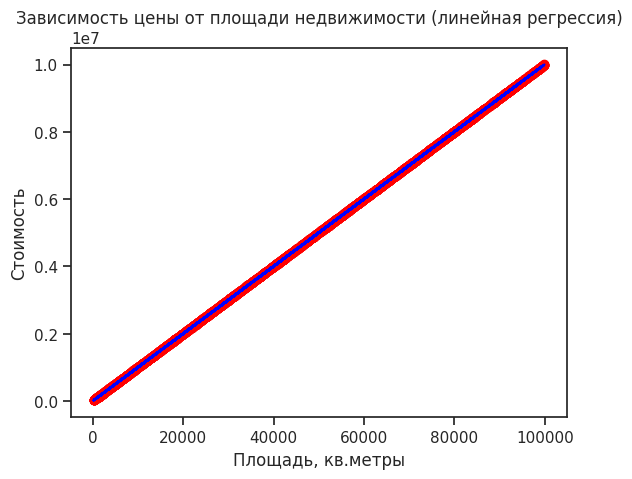

In [ ]:
plt.scatter(x=X_test['squareMeters'], y=y_test, color = 'red')
plt.plot(X_test['squareMeters'], regression_pipeline.predict(X_test), color = 'blue')
plt.title('Зависимость цены от площади недвижимости (линейная регрессия)')
plt.xlabel('Площадь, кв.метры')
plt.ylabel('Стоимость')
plt.show()

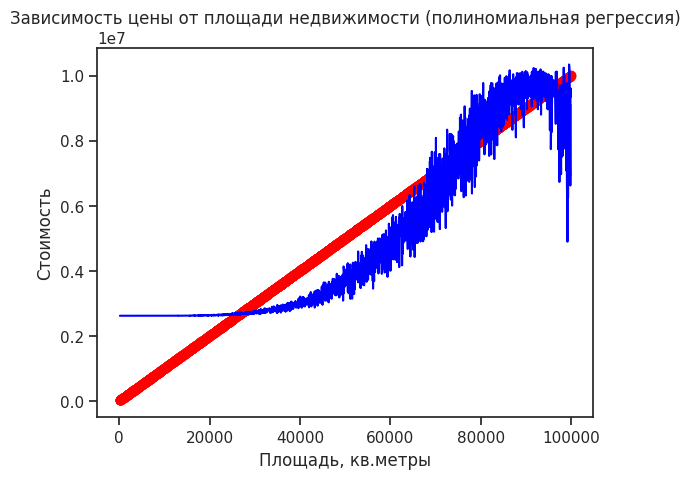

In [ ]:
plt.scatter(x=X_test['squareMeters'], y=y_test, color = 'red')
plt.plot(X_sorted['squareMeters'], regression_pipeline_2.predict(X_sorted), color = 'blue')
plt.title('Зависимость цены от площади недвижимости (полиномиальная регрессия)')
plt.xlabel('Площадь, кв.метры')
plt.ylabel('Стоимость')
plt.show()

Пронаблюдаем за изменением модели при различных степенях полиномы

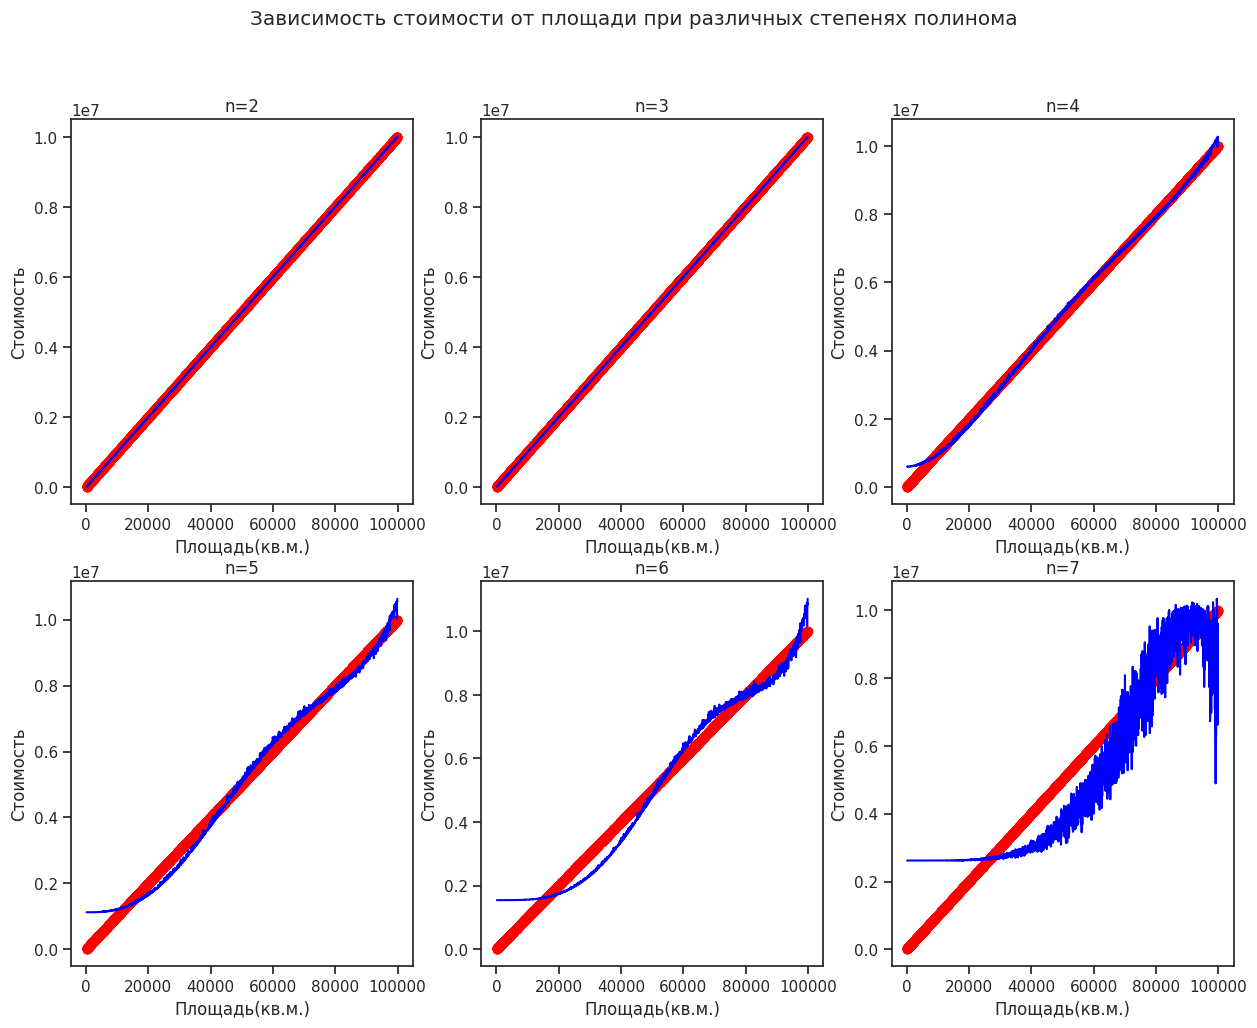

In [ ]:
degrees = [*range(2, 8)]

f, ax= plt.subplots(2, 3)
f.suptitle('Зависимость стоимости от площади при различных степенях полинома')
f.set_figheight(11)
f.set_figwidth(15)

for degree in degrees:
    regression_pipeline_2.set_params(polynomialfeatures__degree=degree)
    regression_pipeline_2.fit(X_train, y_train)

    idx = degree - min(degrees)
    axes = ax[idx // 3][idx % 3]
    axes.scatter(x=X_test['squareMeters'], y=y_test, color = 'red')
    axes.plot(X_sorted['squareMeters'], regression_pipeline_2.predict(X_sorted), color = 'blue')

    axes.set_title(f'n={degree}')
    axes.set_xlabel('Площадь(кв.м.)')
    axes.set_ylabel('Стоимость')
plt.show()

Из представленного анализа следует, что при реализации полиномиальной регрессии нет необходимости в увеличении степени аппроксимации.